1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

2

In [ ]:
df = pd.read_csv("Telecom project.csv")

print(df.shape)
print(df.head())

(4000, 20)
   CustomerID  Age  Tenure  MonthlyCharges  ContractType  Complaints  \
0           1   65      57      431.323553             2           6   
1           2   22      11      397.256679             2           0   
2           3   43      39     2381.255435             1           9   
3           4   21      34      485.470361             2           8   
4           5   37      40      760.144580             0           0   

   Satisfaction       Usage  SupportCalls  LastLoginDays  PaymentDelay  \
0             3  104.005318             1            128             0   
1             8  144.523536             6            349             7   
2             3  245.320198             5            333            12   
3             9  136.393063             4            210             0   
4             3  185.265794             6            238             9   

   Services   Discount  Paperless  Security  TechSupport  Region  Gender  \
0         3  22.530919          0  

3

In [ ]:
imputer = SimpleImputer(strategy='mean')
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

4.

In [ ]:
df['AvgChargePerService'] = df['MonthlyCharges'] / (df['Services'] + 1)


5

In [ ]:
X = df.drop(['CustomerID', 'Churn'], axis=1)
y = df['Churn']

6

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

7

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

8

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

9

In [ ]:
results = []

for name, model in models.items():

    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1, cv_scores.mean()])

    print(f"\n{name}")
    print("CV Score:", cv_scores.mean())
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Logistic Regression
CV Score: 0.9465625
Confusion Matrix:
 [[380  20]
 [ 21 379]]

Decision Tree
CV Score: 0.8674999999999999
Confusion Matrix:
 [[354  46]
 [ 51 349]]

Random Forest
CV Score: 0.92875
Confusion Matrix:
 [[379  21]
 [ 31 369]]

KNN
CV Score: 0.8243750000000001
Confusion Matrix:
 [[339  61]
 [ 81 319]]

Naive Bayes
CV Score: 0.9296875
Confusion Matrix:
 [[370  30]
 [ 34 366]]


10

In [ ]:
results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "CV Score"
])

print(results_df)

                 Model  Accuracy  Precision  Recall  F1 Score  CV Score
0  Logistic Regression   0.94875   0.949875  0.9475  0.948686  0.946562
1        Decision Tree   0.87875   0.883544  0.8725  0.877987  0.867500
2        Random Forest   0.93500   0.946154  0.9225  0.934177  0.928750
3                  KNN   0.82250   0.839474  0.7975  0.817949  0.824375
4          Naive Bayes   0.92000   0.924242  0.9150  0.919598  0.929688


11

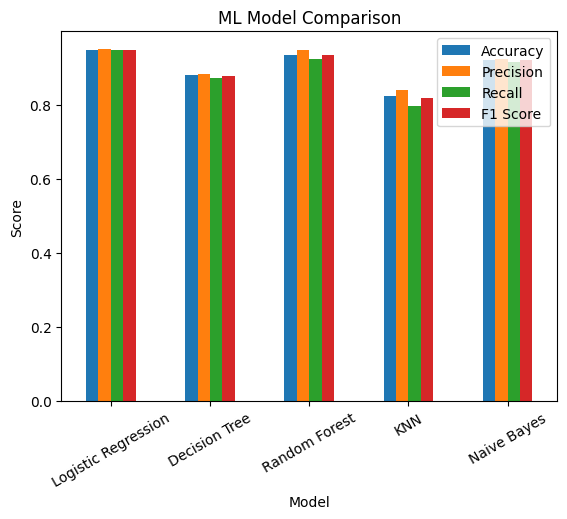

In [ ]:
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind='bar')

plt.title("ML Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()

12

In [ ]:
voting = VotingClassifier(
    estimators=[
        ('lr', models["Logistic Regression"]),
        ('rf', models["Random Forest"]),
        ('knn', models["KNN"])
    ],
    voting='hard'
)

voting.fit(X_train, y_train)
y_pred_ens = voting.predict(X_test)

ens_acc = accuracy_score(y_test, y_pred_ens)
ens_prec = precision_score(y_test, y_pred_ens)
ens_rec = recall_score(y_test, y_pred_ens)
ens_f1 = f1_score(y_test, y_pred_ens)

results.append(["Ensemble", ens_acc, ens_prec, ens_rec, ens_f1, "-"])

13

In [ ]:
best_row = results_df.sort_values(by="F1 Score", ascending=False).iloc[0]

best_model_name = best_row["Model"]
best_model = models[best_model_name]

print("Best ML Model:", best_model_name)

Best ML Model: Logistic Regression


14

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

ann_model = Sequential()

ann_model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
ann_model.add(Dense(16, activation='relu'))
ann_model.add(Dropout(0.2))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5941 - loss: 0.6756 - val_accuracy: 0.8062 - val_loss: 0.5319
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8137 - loss: 0.4675 - val_accuracy: 0.9000 - val_loss: 0.3357
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8832 - loss: 0.3115 - val_accuracy: 0.9312 - val_loss: 0.2201
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9176 - loss: 0.2201 - val_accuracy: 0.9484 - val_loss: 0.1644
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9297 - loss: 0.1799 - val_accuracy: 0.9484 - val_loss: 0.1375
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9438 - loss: 0.1462 - val_accuracy: 0.9469 - val_loss: 0.1211
Epoch 7/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9453 - loss: 0.1333 - val_accuracy: 0.9484 - val_loss: 0.1144
Epoch 8/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9492 - loss: 0.1231 - val_accuracy: 0.9547 - val_loss:

15

In [ ]:
y_pred_ann = ann_model.predict(X_test)
y_pred_ann = (y_pred_ann > 0.5).astype(int)

ann_acc = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann)
ann_rec = recall_score(y_test, y_pred_ann)
ann_f1 = f1_score(y_test, y_pred_ann)

print("\nANN Results")
print("F1 Score:", ann_f1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

ANN Results
F1 Score: 0.9638854296388543


16

In [ ]:
results.append(["ANN (Deep Learning)", ann_acc, ann_prec, ann_rec, ann_f1, "-"])

17

In [ ]:
# Add ANN predictions as feature
ann_train = (ann_model.predict(X_train) > 0.5).astype(int)
ann_test = (ann_model.predict(X_test) > 0.5).astype(int)

X_train_new = np.column_stack((X_train, ann_train))
X_test_new = np.column_stack((X_test, ann_test))

best_model.fit(X_train_new, y_train)
y_pred_int = best_model.predict(X_test_new)

print("\nIntegrated Model F1:",
      f1_score(y_test, y_pred_int))

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Integrated Model F1: 0.9638854296388543


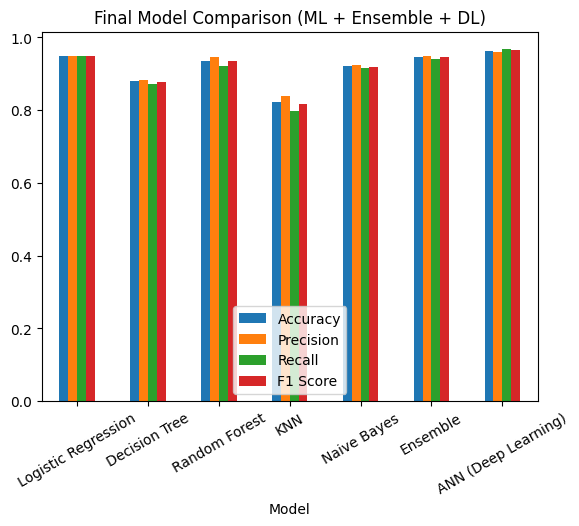

In [ ]:
final_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "CV Score"
])

final_df.set_index("Model")[["Accuracy","Precision","Recall","F1 Score"]].plot(kind='bar')

plt.title("Final Model Comparison (ML + Ensemble + DL)")
plt.xticks(rotation=30)
plt.show()

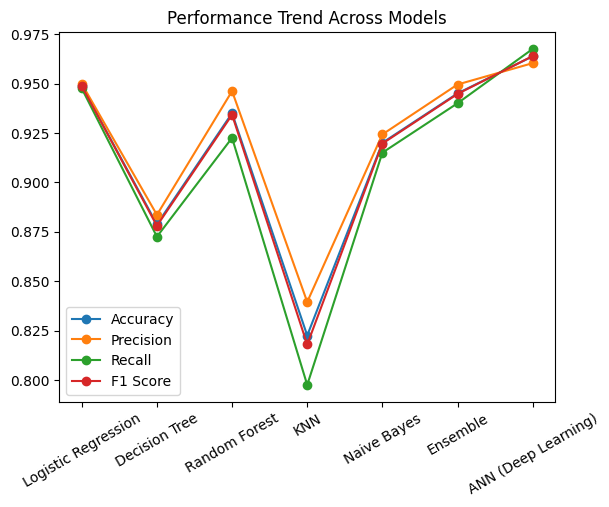

In [ ]:
plt.figure()

plt.plot(final_df["Model"], final_df["Accuracy"], marker='o', label="Accuracy")
plt.plot(final_df["Model"], final_df["Precision"], marker='o', label="Precision")
plt.plot(final_df["Model"], final_df["Recall"], marker='o', label="Recall")
plt.plot(final_df["Model"], final_df["F1 Score"], marker='o', label="F1 Score")

plt.xticks(rotation=30)
plt.title("Performance Trend Across Models")
plt.legend()
plt.show()

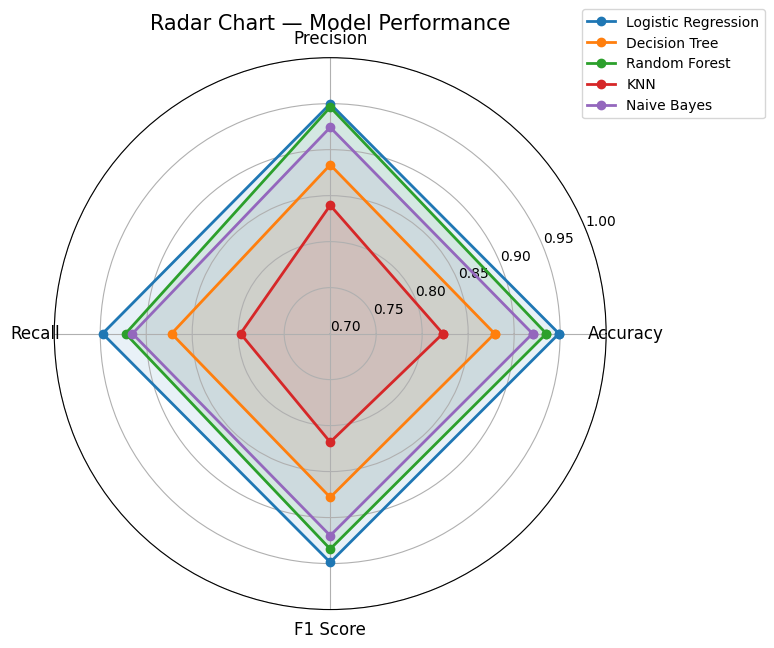

In [ ]:
# ---- NEW GRAPH 1: Radar Chart Comparison ----
import numpy as np
import matplotlib.pyplot as plt

categories = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, row in results_df.iterrows():
    values = row[['Accuracy', 'Precision', 'Recall', 'F1 Score']].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0.7, 1.0)
ax.set_title("Radar Chart — Model Performance", size=15, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

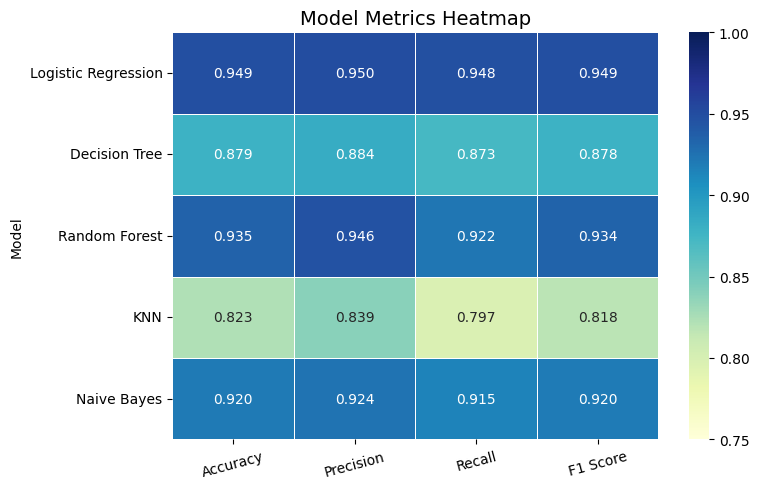

In [ ]:
# ---- NEW GRAPH 2: Heatmap of Metrics ----
import seaborn as sns

heatmap_data = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]]

plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu",
            linewidths=0.5, vmin=0.75, vmax=1.0)
plt.title("Model Metrics Heatmap", fontsize=14)
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

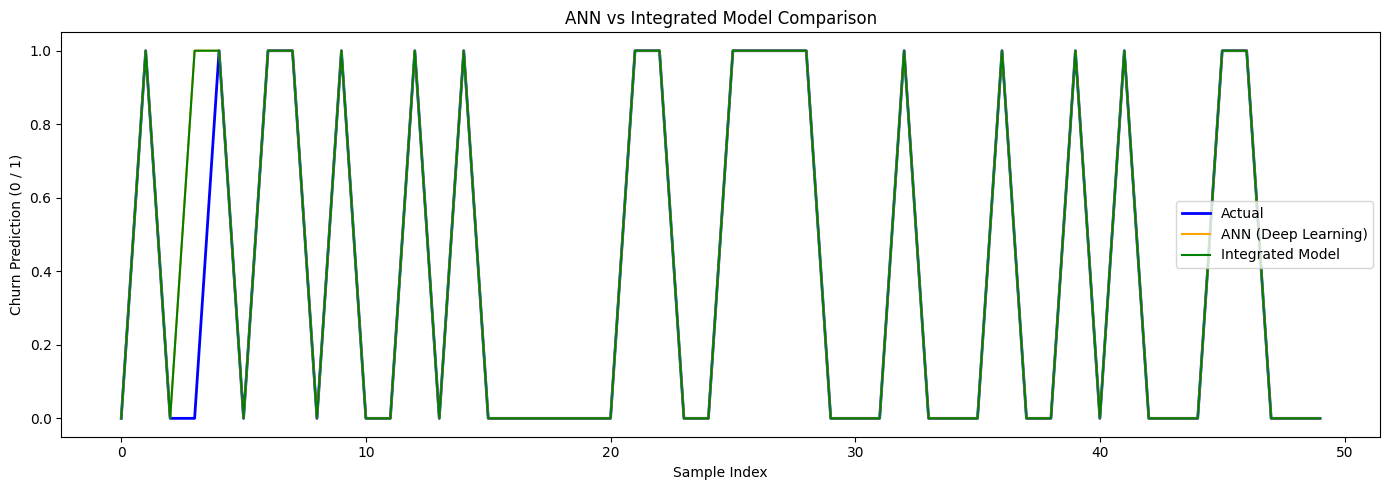

In [ ]:
n = 50
idx = np.arange(n)
actual = np.array(y_test)[:n]

plt.figure(figsize=(14, 5))
plt.plot(idx, actual,              label='Actual',            color='blue',   linewidth=2)
plt.plot(idx, y_pred_ann[:n],      label='ANN (Deep Learning)', color='orange', linewidth=1.5)
plt.plot(idx, y_pred_int[:n],      label='Integrated Model',  color='green',  linewidth=1.5)

plt.title("ANN vs Integrated Model Comparison")
plt.xlabel("Sample Index")
plt.ylabel("Churn Prediction (0 / 1)")
plt.legend()
plt.tight_layout()
plt.show()